Found 46400 images belonging to 29 classes.
Found 11600 images belonging to 29 classes.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 resnet50 (Functional)       (None, 3, 3, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 29)

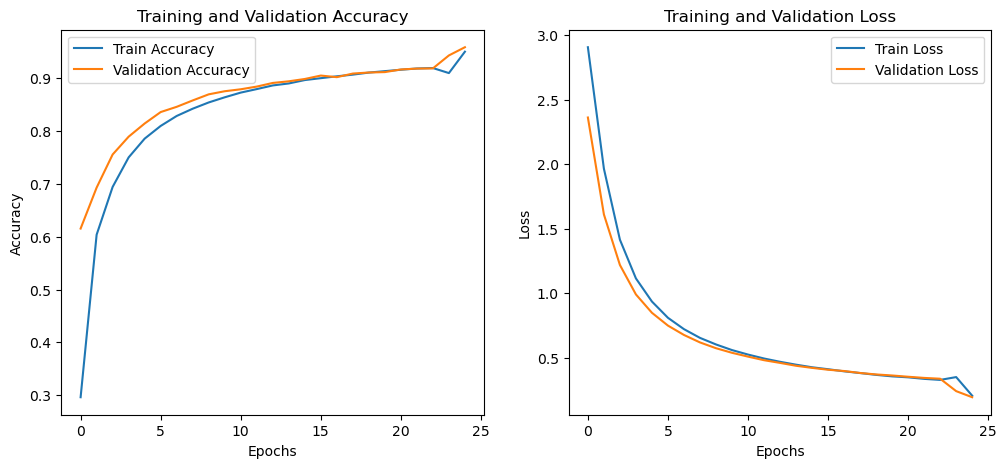

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# --- إعدادات ---
data_dir = r"E:\cnndatasets\char_4K_sample\2000"
img_size = (96, 96)
batch_size = 64
num_classes = 29
initial_epochs = 23
fine_tune_epochs = 2

# --- إنشاء ImageDataGenerator مع تقسيم البيانات ---
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    color_mode='rgb'
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    color_mode='rgb'
)

# --- بناء نموذج ResNet50 مجمد ---
base_model = ResNet50(include_top=False, weights="imagenet", input_shape=img_size + (3,))
base_model.trainable = False

inputs = Input(shape=img_size + (3,))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- كولباكس ---
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=3, verbose=1)

# --- تدريب أولي ---
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=initial_epochs,
    callbacks=[early_stop, reduce_lr]
)

# --- فتح طبقات ResNet50 للتدريب الدقيق ---
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    callbacks=[early_stop, reduce_lr]
)

# --- دمج التاريخ للتدريب ---
history = {}
for key in history1.history.keys():
    history[key] = history1.history[key] + history2.history[key]

# --- رسم المنحنيات ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# --- حفظ النموذج ---
model.save("arabic_chars_resnet50.h5")


182/182 [==============================] - 323s 2s/step


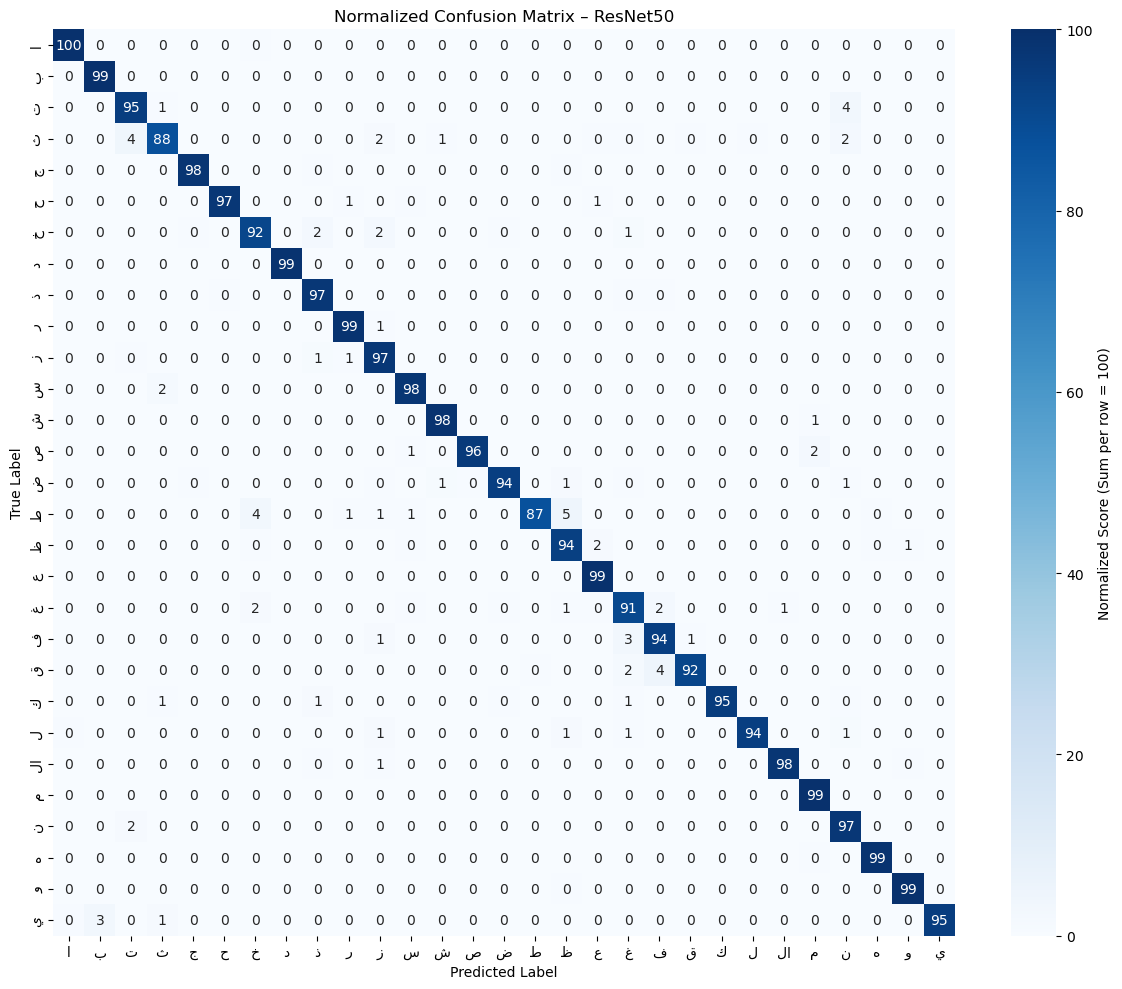

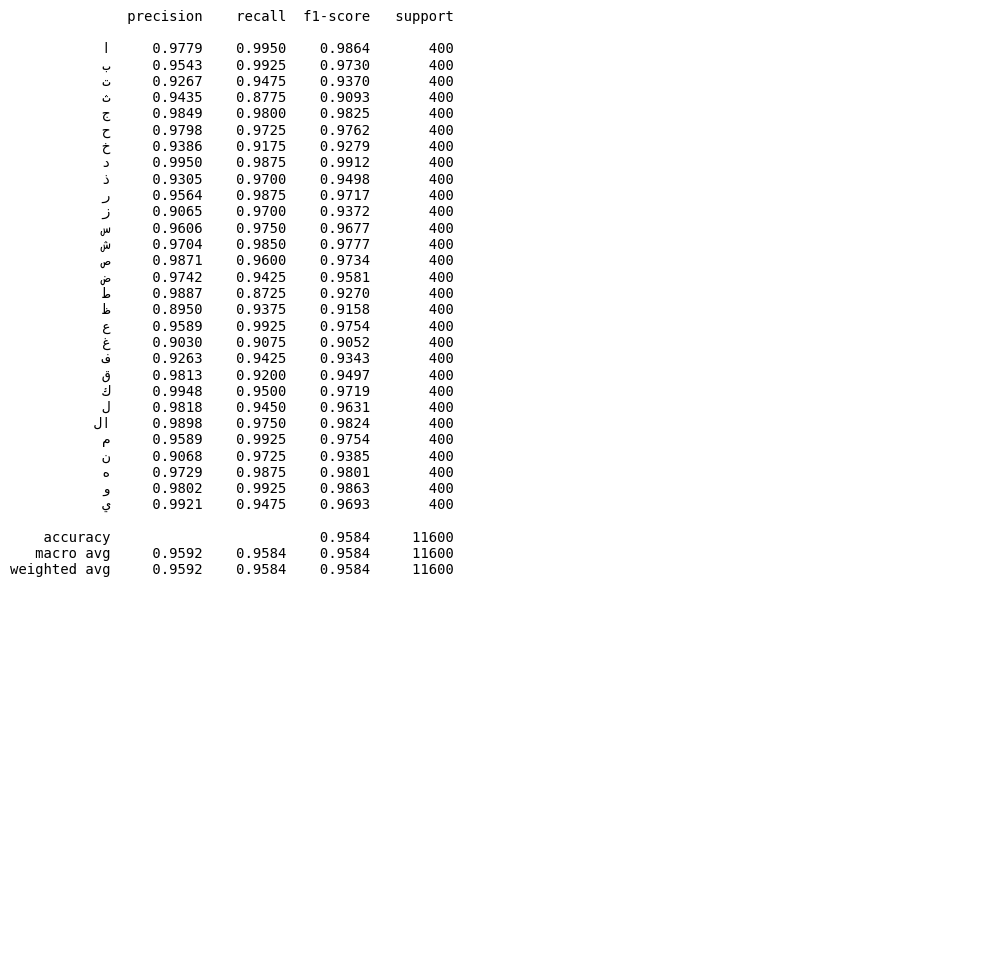

✅ Model structure saved as 'resnet50_model_structure.png'
✅ Training curves saved as 'resnet50_training_curves.png'


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import plot_model

# ------------------- استخراج أسماء الأصناف -------------------
chars = list(val_generator.class_indices.keys())

# ------------------- توقع النموذج -------------------
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# ------------------- مصفوفة الالتباس -------------------
cm = confusion_matrix(y_true, y_pred_classes)

# ------------------- تطبيع المصفوفة -------------------
row_sums = cm.sum(axis=1, keepdims=True)
cm_scaled = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0) * 100

# ------------------- رسم مصفوفة الالتباس -------------------
plt.figure(figsize=(12, 10))
sns.heatmap(cm_scaled, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=chars, yticklabels=chars,
            vmin=0, vmax=100,
            cbar_kws={'label': 'Normalized Score (Sum per row = 100)'})
plt.title('Normalized Confusion Matrix – ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', dpi=300)
plt.show()

# ------------------- تقرير التصنيف -------------------
report_str = classification_report(y_true, y_pred_classes, target_names=chars, digits=4)
fig, ax = plt.subplots(figsize=(10, 0.25 * len(report_str.splitlines()) + 1))
ax.axis('off')
ax.text(0, 1, report_str, fontfamily='monospace', verticalalignment='top')
fig.tight_layout()
fig.savefig('resnet50_classification_report.png', dpi=300)
plt.show()

# ------------------- هيكل النموذج -------------------
plot_model(model, to_file='resnet50_model_structure.png', show_shapes=True, show_layer_names=True)
print("✅ Model structure saved as 'resnet50_model_structure.png'")

# ------------------- رسم منحنيات الدقة والخسارة -------------------
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("resnet50_training_curves.png", dpi=300)
plt.close()
print("✅ Training curves saved as 'resnet50_training_curves.png'")


In [5]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1 (Macro average to treat all classes equally)
precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1 Score (macro): {f1:.4f}")


Accuracy: 0.9584
Precision (macro): 0.9592
Recall (macro): 0.9584
F1 Score (macro): 0.9584
